# Caso comparable: Urbanización y desarrollo de la energía solar en Chile

**Proyecto de Sostenibilidad — Sección 5: Contexto urbano y buenas prácticas / Sostenibilidad Energética**

**Territorio del proyecto:** Departamento de Cortés, Honduras
**Caso comparable analizado en este notebook:** Chile (país)
**Autor:** Diego Díaz
**Fecha de elaboración:** 2026-08-18

---

## 1. Justificación del caso comparable

El lineamiento del proyecto permite documentar "un caso real de datos abiertos aplicados a sostenibilidad
urbana en el territorio **(o uno comparable)**" cuando el territorio elegido no cuenta todavía con series
históricas suficientes.

En el caso de **Cortés, Honduras**, existen instalaciones solares dentro del departamento (por ejemplo,
proyectos industriales y comerciales asociados a la zona de San Pedro Sula), pero **no se identificó un
dataset abierto con una serie histórica confiable** que permita cuantificar cuánto ha aportado la energía
solar a la matriz eléctrica local a lo largo del tiempo. Ese es justamente uno de los "hallazgos/limitaciones"
que este documento deja anotado para la Fase 2 del proyecto (Semana 7 — Sostenibilidad Energética), donde se
buscarán fuentes locales (ENEE, CNE Honduras, SIE) para intentar reconstruir esa serie a nivel de Cortés.

Mientras tanto, se documenta aquí un **caso real y verificable a nivel de país — Chile** — que ilustra de
forma clara y con datos abiertos genuinos cómo se puede analizar la relación entre **urbanización** y
**desarrollo de energía solar** a lo largo del tiempo. Chile es un caso especialmente ilustrativo porque:

- Tiene una de las mayores tasas de irradiación solar del mundo (Desierto de Atacama).
- Pasó de prácticamente 0% de generación eléctrica solar en 2012 a más del 20% en 2023-2024, un cambio
  documentado con datos abiertos año por año.
- Es un país mayoritariamente urbano (~88% de población urbana), lo que permite ilustrar la tensión y
  complementariedad entre demanda energética urbana/industrial y expansión de generación renovable.

Este análisis funciona como **plantilla metodológica**: la misma estructura (fuentes, limpieza, series de
tiempo, gráfico integrador, conclusiones) se reutilizará en la Fase 2 del proyecto para Cortés, Honduras, en
cuanto se identifiquen fuentes locales con series históricas.


## 2. Fuentes de datos y metodología

Todas las fuentes usadas son datos abiertos reales, con licencia identificable. Se documentan según lo exigido
por los lineamientos del proyecto (sección 3.2): portal de origen, formato, licencia, fecha de descarga y
limitaciones conocidas.

| # | Variable | Portal de origen | Formato | Licencia | Fecha de descarga | Limitaciones conocidas |
|---|----------|-------------------|---------|----------|--------------------|--------------------------|
| 1 | Generación de electricidad solar (TWh) y % de la matriz eléctrica proveniente de energía solar, Chile 2005–2024 | **Our World in Data — Energy** (basado en Energy Institute Statistical Review of World Energy y Ember), obtenido vía el repositorio abierto `owid/energy-data` en GitHub | CSV | CC BY 4.0 | 2026-08-18 | El valor de 2025 en la fuente original es preliminar/incompleto y se excluyó de este análisis; cifras sujetas a revisiones posteriores de Ember/Energy Institute. |
| 2 | Población urbana (% del total), Chile 2005–2024 | **World Bank — World Development Indicators**, indicador `SP.URB.TOTL.IN.ZS`, obtenido vía el mirror abierto `datasets/world-development-indicators` en GitHub | CSV | CC BY 4.0 | 2026-08-18 | Estimaciones basadas en definiciones nacionales de "área urbana", que pueden variar entre países (limita comparabilidad directa entre países, no así la serie temporal de un mismo país). |
| 3 | Consumo de energía renovable (% del consumo final de energía), Chile 2017–2021 (contexto adicional) | **World Bank — World Development Indicators**, indicador `EG.FEC.RNEW.ZS`, mismo mirror que la fuente 2 | CSV | CC BY 4.0 | 2026-08-18 | Serie más corta (el mirror disponible no incluye años posteriores a 2021); se usa solo como dato de contexto, no como eje central del análisis. |

**Nota metodológica:** los archivos CSV originales (`owid-energy-data.csv`, `urban_pct.csv`, `renewable_pct.csv`)
se descargaron completos (todos los países) y luego se filtraron únicamente las filas correspondientes a Chile,
guardándolas como archivos independientes en la carpeta `data/` para que este notebook sea reproducible sin
depender de conexión a internet. No se inventó, simuló ni extrapoló ningún dato: todas las cifras provienen
directamente de las fuentes citadas.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Carga de los tres datasets (ya filtrados a Chile, ver seccion 2 para fuentes)
solar = pd.read_csv('data/chile_solar_energia.csv')
urban = pd.read_csv('data/chile_urbanizacion.csv')
renov = pd.read_csv('data/chile_renovables.csv')

print("Energia solar / electricidad:", solar.shape)
display(solar.head())

print("\nUrbanizacion (%):", urban.shape)
display(urban.head())

print("\nEnergia renovable (%), contexto:", renov.shape)
display(renov.head())


Energia solar / electricidad: (20, 10)


,country,year,population,electricity_generation,solar_electricity,solar_share_elec,solar_consumption,solar_cons_change_twh,renewables_share_elec,fossil_share_elec
0,Chile,2005,16348780.0,52.22,0.0,0.0,0.0,0.0,53.658,46.342
1,Chile,2006,16509195.0,55.04,0.0,0.0,0.0,0.0,55.015,44.985
2,Chile,2007,16671571.0,58.28,0.0,0.0,0.0,0.0,43.943,56.057
3,Chile,2008,16838987.0,59.46,0.0,0.0,0.0,0.0,45.526,54.474
4,Chile,2009,17009730.0,60.37,0.0,0.0,0.0,0.0,48.683,51.317



Urbanizacion (%): (20, 4)


,country,code,year,urban_pop_pct
0,Chile,CHL,2005,86.776824
1,Chile,CHL,2006,86.812512
2,Chile,CHL,2007,86.844507
3,Chile,CHL,2008,86.876577
4,Chile,CHL,2009,86.912490



Energia renovable (%), contexto: (17, 4)


,country,code,year,renewable_energy_pct
0,Chile,CHL,2005,32.3
1,Chile,CHL,2006,32.9
2,Chile,CHL,2007,30.5
3,Chile,CHL,2008,30.8
4,Chile,CHL,2009,31.5


## 3. Evolución de la energía solar en Chile (2005–2024)

La siguiente serie muestra dos cosas al mismo tiempo: la generación bruta de electricidad solar (en TWh) y su
participación porcentual dentro de la matriz eléctrica nacional. El quiebre estructural ocurre entre 2013 y
2014, cuando entran en operación los primeros grandes parques solares del norte del país (región de
Atacama/Antofagasta), impulsados por altos niveles de radiación solar y por mecanismos de licitación de
suministro eléctrico.


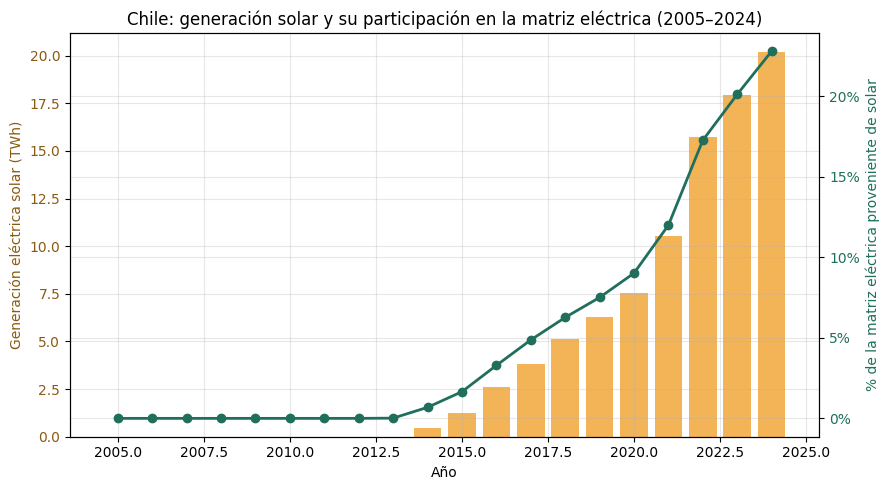

Crecimiento 2013->2024: de 0.01% a 22.78% de la matriz eléctrica.


In [2]:
fig, ax1 = plt.subplots()

ax1.bar(solar['year'], solar['solar_electricity'], color='#F2A73B', alpha=0.85, label='Generacion solar (TWh)')
ax1.set_xlabel('Año')
ax1.set_ylabel('Generación eléctrica solar (TWh)', color='#8a5a12')
ax1.tick_params(axis='y', labelcolor='#8a5a12')

ax2 = ax1.twinx()
ax2.plot(solar['year'], solar['solar_share_elec'], color='#1f6f5c', marker='o', linewidth=2,
         label='% de la matriz eléctrica')
ax2.set_ylabel('% de la matriz eléctrica proveniente de solar', color='#1f6f5c')
ax2.tick_params(axis='y', labelcolor='#1f6f5c')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.title('Chile: generación solar y su participación en la matriz eléctrica (2005–2024)')
fig.tight_layout()
plt.savefig('grafico_solar_chile.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"Crecimiento 2013->2024: de {solar[solar.year==2013]['solar_share_elec'].values[0]:.2f}% a "
      f"{solar[solar.year==2024]['solar_share_elec'].values[0]:.2f}% de la matriz eléctrica.")


## 4. Urbanización en Chile (2005–2024)

Chile es un país altamente urbanizado. La serie del Banco Mundial muestra un crecimiento sostenido pero lento
(a diferencia del "boom" solar, que fue explosivo). Esto es esperable: la urbanización es un proceso estructural
de décadas, mientras que la generación solar puede expandirse mucho más rápido cuando existe la política pública
y la inversión adecuadas.


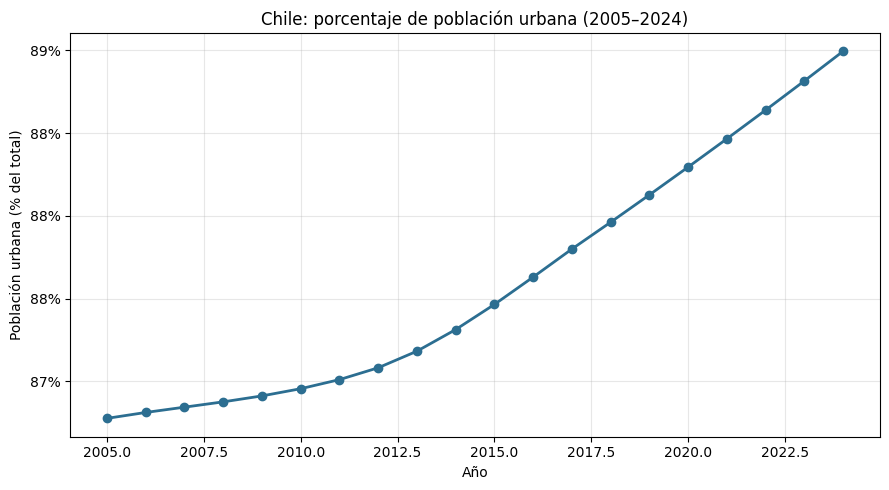

Variacion 2005->2024: +2.22 puntos porcentuales de poblacion urbana.


In [3]:
fig, ax = plt.subplots()
ax.plot(urban['year'], urban['urban_pop_pct'], color='#2c6e91', marker='o', linewidth=2)
ax.set_xlabel('Año')
ax.set_ylabel('Población urbana (% del total)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_title('Chile: porcentaje de población urbana (2005–2024)')
plt.tight_layout()
plt.savefig('grafico_urbanizacion_chile.png', dpi=140, bbox_inches='tight')
plt.show()

delta = urban[urban.year==2024]['urban_pop_pct'].values[0] - urban[urban.year==2005]['urban_pop_pct'].values[0]
print(f"Variacion 2005->2024: +{delta:.2f} puntos porcentuales de poblacion urbana.")


## 5. Análisis integrador: urbanización y energía solar en la misma línea de tiempo

Al superponer ambas series se observa un patrón típico de países en transición energética: la urbanización
crece de forma **lineal y gradual**, mientras que la energía solar crece de forma **exponencial** una vez que
se cruza un umbral de política pública/inversión (~2013–2014 en el caso chileno). Esto sugiere que el
crecimiento urbano por sí solo no explica el despegue solar — lo que lo explica es la combinación de:
recurso natural (radiación solar en el norte del país), marco regulatorio (licitaciones de suministro eléctrico,
Ley 20.257 de fomento a energías renovables no convencionales) y demanda eléctrica creciente de ciudades y
zonas industriales/mineras.


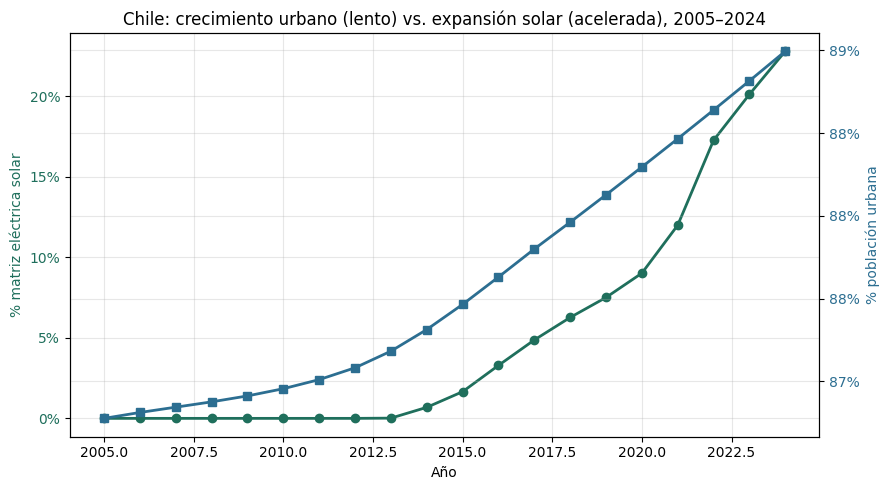

Correlacion (Pearson) entre % urbanizacion y % solar en la matriz, 2005-2024: 0.951
Nota: una correlacion alta aqui refleja que ambas variables crecen con el tiempo, NO una relacion causal directa.


In [4]:
fig, ax1 = plt.subplots()

ax1.plot(solar['year'], solar['solar_share_elec'], color='#1f6f5c', marker='o', linewidth=2,
         label='% matriz eléctrica solar')
ax1.set_xlabel('Año')
ax1.set_ylabel('% matriz eléctrica solar', color='#1f6f5c')
ax1.tick_params(axis='y', labelcolor='#1f6f5c')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

ax2 = ax1.twinx()
ax2.plot(urban['year'], urban['urban_pop_pct'], color='#2c6e91', marker='s', linewidth=2,
         label='% población urbana')
ax2.set_ylabel('% población urbana', color='#2c6e91')
ax2.tick_params(axis='y', labelcolor='#2c6e91')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.title('Chile: crecimiento urbano (lento) vs. expansión solar (acelerada), 2005–2024')
fig.tight_layout()
plt.savefig('grafico_integrador_chile.png', dpi=140, bbox_inches='tight')
plt.show()

# Correlacion simple como referencia (no implica causalidad)
merged = solar.merge(urban[['year','urban_pop_pct']], on='year')
corr = merged['solar_share_elec'].corr(merged['urban_pop_pct'])
print(f"Correlacion (Pearson) entre % urbanizacion y % solar en la matriz, 2005-2024: {corr:.3f}")
print("Nota: una correlacion alta aqui refleja que ambas variables crecen con el tiempo, NO una relacion causal directa.")


## 6. Contexto cualitativo del caso chileno

- **Recurso natural:** el desierto de Atacama tiene algunos de los niveles de radiación solar más altos del
  planeta, lo que hizo económicamente viables plantas solares de gran escala desde ~2013.
- **Política pública:** licitaciones de suministro eléctrico de largo plazo y marcos de fomento a energías
  renovables no convencionales (ERNC) redujeron el riesgo de inversión y permitieron contratos a precios
  competitivos.
- **Demanda concentrada:** buena parte de la demanda eléctrica del norte de Chile proviene de la gran minería
  (industria intensiva en energía), un factor distinto al caso de Cortés, Honduras, donde la demanda urbana e
  industrial (maquila, zonas francas) tiene otra escala y estructura.

Estos tres factores — recurso, política y demanda — son exactamente las tres preguntas que conviene formular
para el propio territorio (Cortés, Honduras) en la Fase 2 del proyecto.


## 7. Aplicación al territorio propio: Cortés, Honduras

Este caso comparable deja un mapa de ruta claro para la Semana 7 (Sostenibilidad Energética) del Parcial 2,
cuando se debe "analizar consumo/generación renovable del territorio y proponer una mejora basada en datos":

**Preguntas guía para investigar con fuentes locales:**

1. ¿Qué plantas solares existen dentro de Cortés (o que alimenten su red) y cuándo entraron en operación?
   Fuentes a explorar: **ENEE** (Empresa Nacional de Energía Eléctrica), **CNE** (Comisión Nacional de Energía
   de Honduras), informes de la **SIE** (Secretaría de Energía).
2. ¿Existen series históricas de generación por tipo de fuente (hidro, térmica, solar, eólica) publicadas por
   ENEE o el Operador del Sistema? Si no hay series abiertas a nivel de departamento, ¿hay series a nivel
   nacional que permitan al menos estimar la tendencia?
3. ¿Cómo se relaciona el crecimiento urbano/industrial de San Pedro Sula y su área metropolitana con la demanda
   eléctrica y con el interés en generación distribuida (techos solares en zonas francas e industria)?

**Nota metodológica importante:** si al buscar en estas fuentes no se encuentra una serie histórica confiable
y verificable, esa ausencia de datos **debe declararse explícitamente** en el Informe de Diagnóstico (no se
debe inventar ni extrapolar), tal como indican los lineamientos del proyecto (sección 3.2). En ese caso, este
notebook —con el caso de Chile— sirve como evidencia de que sí se investigó el tema en profundidad y como
plantilla metodológica lista para aplicar en cuanto aparezcan fuentes locales con series de tiempo.


## 8. Conclusiones

- Chile ilustra, con datos abiertos verificables, cómo una combinación de recurso natural + política pública
  puede llevar la generación solar de ~0% a más del 20% de la matriz eléctrica en poco más de una década
  (2013–2024).
- La urbanización, en contraste, es un proceso mucho más lento y estable (crecimiento de ~2 puntos porcentuales
  en 20 años), lo que confirma que **no es el crecimiento urbano el que impulsa la energía solar**, sino
  decisiones de política energética e inversión concentradas en zonas de alto recurso solar.
- Para Cortés, Honduras, el siguiente paso metodológico es replicar exactamente esta estructura (fuentes →
  limpieza → series de tiempo → gráfico integrador → conclusiones) en cuanto se identifiquen fuentes locales
  (ENEE/CNE/SIE) con series históricas reales.

### Limitaciones de este análisis

- Es un análisis a **nivel de país** (Chile), no a nivel de departamento/ciudad; sirve como caso comparable e
  ilustrativo, no como sustituto de datos propios de Cortés.
- La serie de energía renovable (sección 2, fuente 3) solo llega hasta 2021 en el mirror de datos disponible.
- El dato de 2025 de generación solar se excluyó por estar incompleto/preliminar en la fuente original.
- La correlación calculada en la sección 5 es puramente descriptiva; no controla por otras variables (precio
  del cobre, políticas específicas, crisis energéticas, etc.) y no debe interpretarse como causalidad.


## 9. Referencias (formato APA)

Energy Institute. (2025). *Statistical Review of World Energy* [Conjunto de datos]. Recuperado el 18 de agosto
de 2026, a través de Our World in Data, github.com/owid/energy-data. https://ourworldindata.org/energy

Ember. (2025). *Yearly electricity data* [Conjunto de datos]. Recuperado el 18 de agosto de 2026, a través de
Our World in Data, github.com/owid/energy-data. https://ember-energy.org

World Bank. (2025). *Urban population (% of total population)* [Conjunto de datos]. World Development
Indicators, indicador SP.URB.TOTL.IN.ZS. Recuperado el 18 de agosto de 2026, a través del mirror abierto
github.com/datasets/world-development-indicators. https://data.worldbank.org/indicator/SP.URB.TOTL.IN.ZS

World Bank. (2025). *Renewable energy consumption (% of total final energy consumption)* [Conjunto de datos].
World Development Indicators, indicador EG.FEC.RNEW.ZS. Recuperado el 18 de agosto de 2026, a través del mirror
abierto github.com/datasets/world-development-indicators. https://data.worldbank.org/indicator/EG.FEC.RNEW.ZS
